In [1]:
import pandas as pd
df = pd.read_csv('Ice_cream selling data.csv')
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [2]:
from sklearn.linear_model import LinearRegression

In [3]:
x = df['Temperature (°C)'].values.reshape(-1, 1)
Y = df['Ice Cream Sales (units)']

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size = 0.2,random_state =42)

In [6]:
model = LinearRegression()
model

LinearRegression()

In [7]:
model_fit = model.fit(x_train, Y_train)
model_fit

LinearRegression()

In [8]:
Y_pred_linear = model.predict(x_test) 
Y_pred_linear

array([19.2247831 , 12.89218952, 12.39975758, 12.99914196, 18.0259032 ,
       15.96490086, 16.13605851, 16.34394177, 15.0173946 , 17.3107825 ])

In [9]:
from sklearn.preprocessing import PolynomialFeatures

In [10]:
poly = PolynomialFeatures(degree = 2)
poly

PolynomialFeatures()

In [11]:
x_train_poly = poly.fit_transform(x_train)
x_train_poly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [12]:
x_test_poly = poly.transform(x_test)
x_test_poly

array([[ 1.        , -1.81893761,  3.30853403],
       [ 1.        ,  3.70405744, 13.72004151],
       [ 1.        ,  4.13353379, 17.08610158],
       [ 1.        ,  3.61077848, 13.03772121],
       [ 1.        , -0.77333004,  0.59803936],
       [ 1.        ,  1.02418081,  1.04894634],
       [ 1.        ,  0.87490503,  0.76545881],
       [ 1.        ,  0.69359887,  0.4810794 ],
       [ 1.        ,  1.85055193,  3.42454243],
       [ 1.        , -0.14963487,  0.02239059]])

In [13]:
model_poly = LinearRegression()
model_poly

LinearRegression()

In [14]:
model_poly.fit(x_train_poly,Y_train)
x_test_poly = poly.transform(x_test)

In [15]:
x_test_poly

array([[ 1.        , -1.81893761,  3.30853403],
       [ 1.        ,  3.70405744, 13.72004151],
       [ 1.        ,  4.13353379, 17.08610158],
       [ 1.        ,  3.61077848, 13.03772121],
       [ 1.        , -0.77333004,  0.59803936],
       [ 1.        ,  1.02418081,  1.04894634],
       [ 1.        ,  0.87490503,  0.76545881],
       [ 1.        ,  0.69359887,  0.4810794 ],
       [ 1.        ,  1.85055193,  3.42454243],
       [ 1.        , -0.14963487,  0.02239059]])

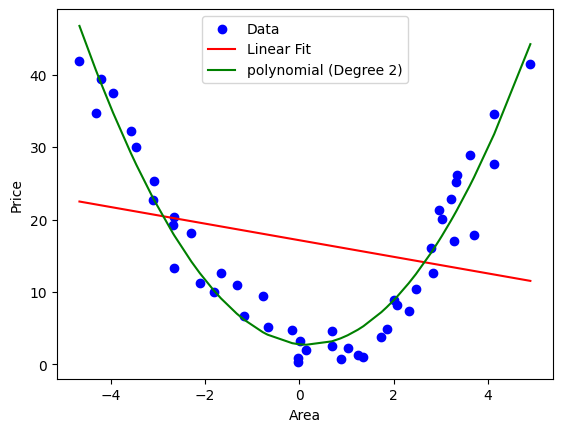

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(x,Y,color='blue',label='Data')
plt.plot(x,model.predict(x),color='red',label='Linear Fit ')
plt.plot(x,model_poly.predict(poly.transform(x)),color= 'green',label='polynomial (Degree 2)')
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.show()